# **==== PRAKTIKUM 1 BIG DATA ====**

## J-1. Verifikasi Lingkungan Kerja

Pada langkah ini dilakukan pemeriksaan terhadap lingkungan kerja Google Colab, meliputi versi Python, sistem operasi, jumlah CPU core, versi library, kapasitas RAM, disk, dan versi Java.

In [4]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [5]:
!free -h        # kapasitas dan sisa RAM
!df -h /content # kapasitas dan sisa disk runtime
!java -version  # dibutuhkan PySpark pada langkah K-8

               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.5Gi       5.2Gi       2.5Mi       6.3Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   22G   87G  20% /
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


## J-2. Menghubungkan Google Drive dan Menyiapkan Struktur Folder

Pada langkah ini Google Drive dihubungkan ke Google Colab dan folder kerja serta folder penyimpanan hasil praktikum disiapkan.

In [7]:
from google.colab import drive
drive.mount("/content/drive")             # ikuti dialog izin yang muncul

import os
DIR_KERJA  = "/content/data"                                      # sementara, cepat
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"         # permanen
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
['Copy of BD_A_P01_2411531009_PutriBalqisAfradinata.ipynb']


## J-3. Menyiapkan Alat Ukur Waktu dan Memori

Pada langkah ini disiapkan fungsi untuk mengukur durasi eksekusi dan perubahan penggunaan memori selama proses pengolahan data.

In [8]:
import time, os, psutil

proses = psutil.Process(os.getpid())
catatan = []         # menyimpan hasil pengukuran untuk dibandingkan nanti

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    delta = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

## J-4. Mengunduh Dataset dan Inspeksi Awal

Pada langkah ini dataset NYC TLC Yellow Taxi Trip Records diunduh secara terprogram dan diperiksa ukuran file, jumlah baris, jumlah kolom, serta nama kolomnya.

In [9]:
import urllib.request

URL = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
       "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.39 s | RSS +1.7 MB
Ukuran file: 45.5 MB


In [10]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


## J-5. Memuat Data dan Mengukur Biaya Memori

Pada langkah ini dilakukan perbandingan penggunaan memori ketika seluruh kolom dimuat dengan ketika hanya kolom yang dibutuhkan yang dimuat. Selanjutnya dilakukan optimasi tipe data untuk mengurangi penggunaan memori.

In [11]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh                                      # bebaskan memori sebelum percobaan kedua
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 1.37 s | RSS +498.8 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.58 s | RSS +205.0 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [12]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2  # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [13]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]   = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount",
            "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


## J-6. Pemeriksaan Kualitas Data dan Pembersihan

Pada langkah ini dilakukan pemeriksaan kualitas data dengan menghitung durasi perjalanan, nilai kosong, serta beberapa kondisi anomali. Data kemudian disaring menggunakan threshold yang telah ditentukan pada modul.

In [14]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                      df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"          : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"  : (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0"   : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [15]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    (df["durasi_menit"].between(1, 180) &
     (df["total_amount"] > 0))
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


## J-7. Memproses File Lebih Besar dari Memori dengan Chunking

Pada langkah ini data bersih ditulis ke dalam format CSV yang berukuran lebih besar, kemudian diproses menggunakan teknik chunking agar hanya sebagian data yang berada di memori pada satu waktu.

In [16]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV) / 1024**2, 1), "MB")

[tulis CSV] 43.56 s | RSS +5.8 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [17]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 3.97 s | RSS +11.2 MB
2,986,911 baris | rata-rata total_amount = 27.33


## J-8. Pendekatan Terdistribusi: PySpark Local Mode

Pada langkah ini dilakukan pengolahan data menggunakan PySpark dalam local mode untuk membandingkan pendekatan Spark dengan pengolahan menggunakan pandas.

In [22]:
!pip install -q pyspark==3.5.1
!java -version

[0.002s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.002s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [23]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")                 # semua core mesin ini
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [24]:
spark.conf.set("spark.sql.parquet.inferTimestampNTZ.enabled", "false")

In [25]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("long")
         - F.col("tpep_pickup_datetime").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 0.47 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+---+------

In [26]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()       # rencana eksekusi – perhatikan Exchange / HashAggregate
spark.stop()                # bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#147 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#147 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=241]
      +- HashAggregate(keys=[jam#147], functions=[count(1), avg(trip_distance#67), avg(total_amount#79)])
         +- Exchange hashpartitioning(jam#147, 8), ENSURE_REQUIREMENTS, [plan_id=238]
            +- HashAggregate(keys=[jam#147], functions=[partial_count(1), partial_avg(trip_distance#67), partial_avg(total_amount#79)])
               +- Project [trip_distance#67, total_amount#79, hour(tpep_pickup_datetime#

## J-9. Agregasi Akhir dengan Pandas dan Penyimpanan Artefak

Pada langkah ini dilakukan agregasi jumlah perjalanan, rata-rata jarak, rata-rata durasi, rata-rata tarif, dan median tarif berdasarkan jam. Hasil kemudian disimpan dalam format CSV, Parquet, dan catatan pengukuran kinerja.

In [27]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


## J-10. Visualisasi Hasil

Pada langkah ini dibuat visualisasi distribusi jumlah perjalanan berdasarkan jam untuk melihat pola permintaan perjalanan selama satu hari.

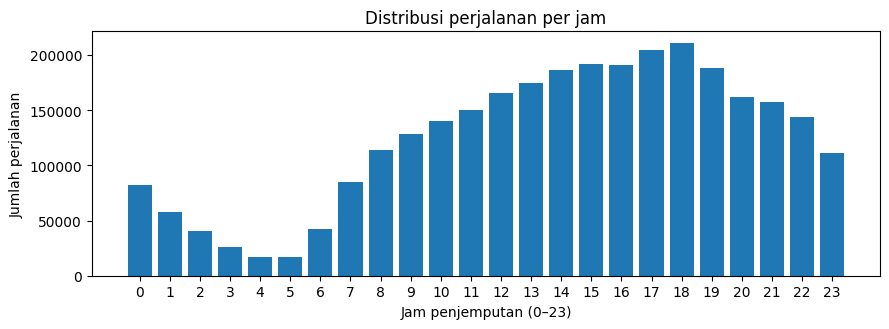

In [28]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

### O. Studi Kasus — Penjadwalan Armada oleh Operator Taksi

Analisis dilakukan untuk mengetahui pola permintaan perjalanan berdasarkan jam dan hari, serta membandingkan durasi dan tarif perjalanan sebagai dasar penyusunan jadwal armada.

In [29]:
bersih["hari"] = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"] = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)
ringkas = (bersih
.groupby(["akhir_pekan", "jam"])
.agg(jumlah=("total_amount", "size"),
rata_durasi=("durasi_menit", "mean"),
rata_tarif_per_menit=("tarif_per_menit", "mean"))
.round(2))
ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

In [30]:
# Ringkasan jam tertinggi dan terendah untuk hari kerja dan akhir pekan
for status, data in ringkas.groupby(level="akhir_pekan"):
    nama = "Akhir pekan" if status else "Hari kerja"
    print(f"\n{nama}")
    print("Jam dengan permintaan tertinggi:")
    print(data["jumlah"].idxmax())
    print("Jumlah perjalanan:", data["jumlah"].max())
    print("Jam dengan permintaan terendah:")
    print(data["jumlah"].idxmin())
    print("Jumlah perjalanan:", data["jumlah"].min())


Hari kerja
Jam dengan permintaan tertinggi:
(np.False_, np.int32(18))
Jumlah perjalanan: 159457
Jam dengan permintaan terendah:
(np.False_, np.int32(4))
Jumlah perjalanan: 6192

Akhir pekan
Jam dengan permintaan tertinggi:
(np.True_, np.int32(16))
Jumlah perjalanan: 54057
Jam dengan permintaan terendah:
(np.True_, np.int32(5))
Jumlah perjalanan: 4478


In [31]:
perbandingan_jumlah = ringkas["jumlah"].unstack(level="akhir_pekan")
perbandingan_jumlah.columns = ["Hari kerja", "Akhir pekan"]

perbandingan_jumlah

,Hari kerja,Akhir pekan
jam,,
0,35351,46938
1,17516,40250
2,9452,30993
3,6238,19908
4,6192,10426
5,12462,4478
6,35728,6572
7,74157,10412
8,98431,15633


In [32]:
perbandingan_tarif = ringkas.reset_index()

perbandingan_tarif["jam_sibuk"] = (
    perbandingan_tarif["jam"].isin([16, 17, 18, 19])
)

perbandingan_tarif.groupby("jam_sibuk").agg(
    rata_durasi=("rata_durasi", "mean"),
    rata_tarif_per_menit=("rata_tarif_per_menit", "mean"),
    jumlah_perjalanan=("jumlah", "sum")
).round(2)

,rata_durasi,rata_tarif_per_menit,jumlah_perjalanan
jam_sibuk,,,
False,13.81,2.29,2192618
True,15.23,2.08,794293


Grafik jumlah perjalanan per jam

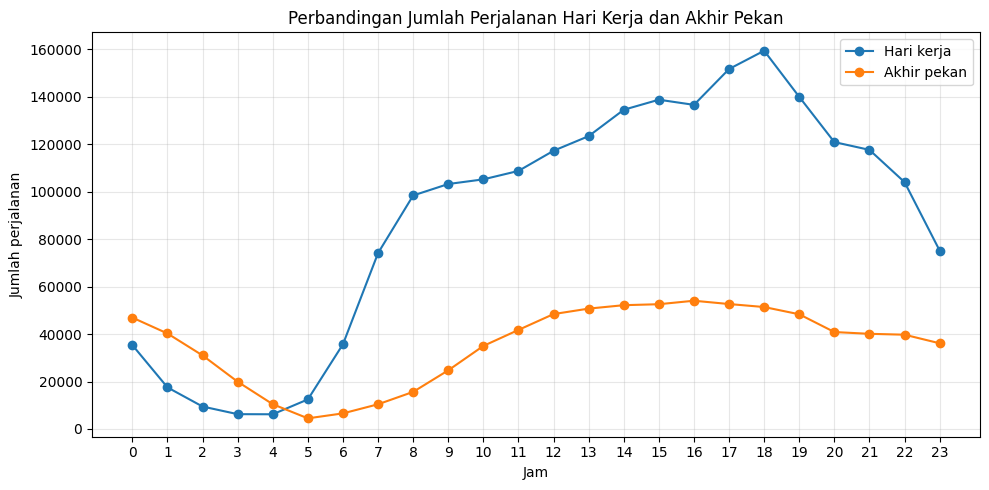

In [33]:
import matplotlib.pyplot as plt

grafik_jumlah = perbandingan_jumlah

grafik_jumlah.plot(figsize=(10, 5), marker="o")
plt.xlabel("Jam")
plt.ylabel("Jumlah perjalanan")
plt.title("Perbandingan Jumlah Perjalanan Hari Kerja dan Akhir Pekan")
plt.xticks(range(24))
plt.legend(title="")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Grafik durasi vs tarif per menit

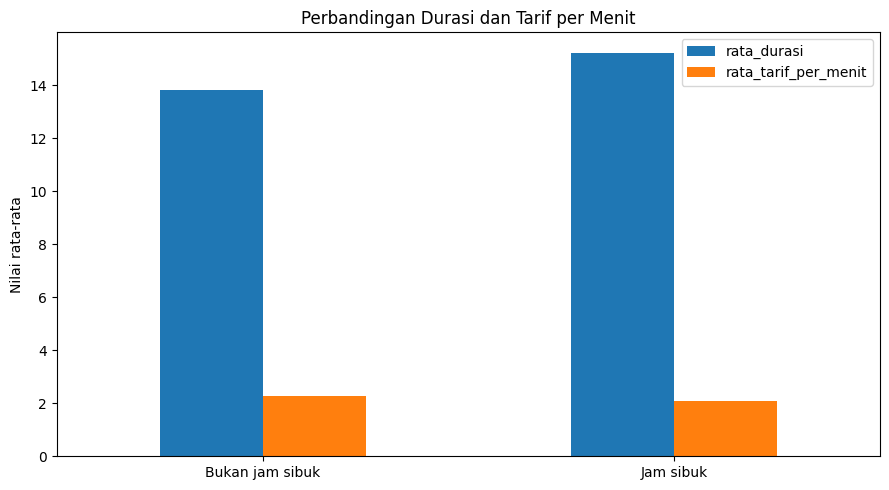

In [34]:
perbandingan_busy = perbandingan_tarif.groupby("jam_sibuk").agg(
    rata_durasi=("rata_durasi", "mean"),
    rata_tarif_per_menit=("rata_tarif_per_menit", "mean")
).round(2)

perbandingan_busy.index = ["Bukan jam sibuk", "Jam sibuk"]

perbandingan_busy.plot(kind="bar", figsize=(9, 5))
plt.xlabel("")
plt.ylabel("Nilai rata-rata")
plt.title("Perbandingan Durasi dan Tarif per Menit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## **LATIHAN**

## P. Latihan

### Latihan 1 — Lima Trip Distance Terbesar

Menampilkan lima perjalanan dengan nilai trip_distance terbesar pada data bersih untuk melihat karakteristik perjalanan dengan jarak terjauh.

In [35]:
terbesar = bersih.nlargest(5, "trip_distance")

terbesar

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount,durasi_menit,jam,hari,akhir_pekan,tarif_per_menit
1748933,2023-01-19 16:29:36,2023-01-19 18:46:01,1.0,96.70,1,350.000000,50.0,440.750000,136.416667,16,Thursday,False,3.231
526988,2023-01-07 04:29:56,2023-01-07 06:06:16,2.0,93.05,2,542.000000,0.0,564.049988,96.333333,4,Saturday,True,5.855
2402193,2023-01-26 04:55:45,2023-01-26 07:18:50,1.0,92.60,1,262.500000,20.0,312.799988,143.083333,4,Thursday,False,2.186
2902389,2023-01-31 07:04:24,2023-01-31 09:32:54,1.0,92.00,1,334.100006,10.0,368.149994,148.500000,7,Tuesday,False,2.479
927215,2023-01-11 14:23:55,2023-01-11 16:17:58,1.0,90.63,2,250.000000,0.0,272.299988,114.050000,14,Wednesday,False,2.388


Kelima perjalanan memiliki jarak yang sangat jauh, yaitu sekitar 90–97, sehingga tergolong perjalanan ekstrem tetapi masih memenuhi batas pembersihan data yang ditetapkan (trip_distance < 100 dan durasi 1–180 menit).

### Latihan 2 — Perbandingan Ukuran Chunk

Membandingkan waktu dan penggunaan memori pada proses chunking dengan ukuran 100.000 dan 1.000.000 baris.

In [36]:
import time
import psutil
import os
import pandas as pd

proses = psutil.Process(os.getpid())

def ukur_chunking(ukuran_chunk):
    mulai = time.perf_counter()
    rss_awal = proses.memory_info().rss / 1024**2

    total_baris = 0
    total_nilai = 0.0

    potongan = pd.read_csv(
        CSV,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk
    )

    for chunk in potongan:
        total_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()

    waktu = time.perf_counter() - mulai
    rss_akhir = proses.memory_info().rss / 1024**2

    return total_baris, total_nilai, waktu, rss_akhir - rss_awal

hasil_100k = ukur_chunking(100_000)
hasil_1m = ukur_chunking(1_000_000)

print("Chunk 100.000 :", hasil_100k)
print("Chunk 1.000.000:", hasil_1m)

Chunk 100.000 : (2986911, np.float64(81621456.74000004), 4.284271983000053, 38.953125)
Chunk 1.000.000: (2986911, np.float64(81621456.73999998), 4.344426817999647, 55.77734375)


Penggunaan chunksize=100.000 sedikit lebih cepat dan menggunakan memori lebih rendah dibandingkan chunksize=1.000.000. Ukuran chunk yang lebih besar tidak selalu lebih cepat, tetapi membutuhkan memori lebih besar sehingga trade-off-nya adalah antara efisiensi waktu dan penggunaan memori.

### Latihan 3 — Persentase Tip berdasarkan Payment Type

Menghitung persentase tip terhadap fare_amount dan membandingkan rata-rata persentase tip berdasarkan metode pembayaran.

In [37]:
import numpy as np

bersih["persen_tip"] = np.where(
    bersih["fare_amount"] == 0,
    np.nan,
    bersih["tip_amount"] / bersih["fare_amount"] * 100
)

rata_tip = (
    bersih.groupby("payment_type")["persen_tip"]
    .mean()
    .round(2)
)

rata_tip

/tmp/ipykernel_8848/3319580548.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bersih.groupby("payment_type")["persen_tip"]


,persen_tip
payment_type,
0,20.219999
1,25.910000
2,0.000000
3,0.020000
4,0.150000


Dugaan: Perjalanan dengan payment_type 1 cenderung memiliki persentase tip lebih tinggi dibandingkan payment type lainnya.

### Latihan 4 — Perbandingan Kompresi Parquet

Menyimpan data bersih dalam format Parquet menggunakan kompresi Snappy dan Gzip, kemudian membandingkan ukuran file dan waktu penulisannya.

In [40]:
import time
import os

PARQUET_SNAPPY = os.path.join(DIR_KERJA, "bersih_snappy.parquet")
PARQUET_GZIP = os.path.join(DIR_KERJA, "bersih_gzip.parquet")

t0 = time.perf_counter()
bersih.to_parquet(PARQUET_SNAPPY, index=False, compression="snappy")
waktu_snappy = time.perf_counter() - t0

t0 = time.perf_counter()
bersih.to_parquet(PARQUET_GZIP, index=False, compression="gzip")
waktu_gzip = time.perf_counter() - t0

ukuran_snappy = os.path.getsize(PARQUET_SNAPPY) / 1024**2
ukuran_gzip = os.path.getsize(PARQUET_GZIP) / 1024**2

print(f"Snappy : {ukuran_snappy:.1f} MB | {waktu_snappy:.2f} s")
print(f"Gzip   : {ukuran_gzip:.1f} MB | {waktu_gzip:.2f} s")

Snappy : 63.3 MB | 2.66 s
Gzip   : 51.0 MB | 41.11 s


Gzip menghasilkan file yang lebih kecil (51,0 MB dibandingkan 63,3 MB), tetapi waktu penulisannya jauh lebih lama (41,11 detik dibandingkan 2,66 detik), sehingga Snappy lebih unggul untuk kecepatan sedangkan Gzip lebih unggul dalam penghematan ruang penyimpanan.

### Latihan 5 — Perbandingan Agregasi Pandas dan Spark SQL

Menulis ulang agregasi per jam menggunakan Spark SQL dan membandingkan hasil jumlah perjalanan dengan hasil agregasi Pandas dari J-9.

In [42]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01-Latihan5")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

spark.conf.set("spark.sql.parquet.inferTimestampNTZ.enabled", "false")

sdf = spark.read.parquet(PATH)

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("long")
         - F.col("tpep_pickup_datetime").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

sdf_bersih.createOrReplaceTempView("trips")

hasil_sql = spark.sql("""
    SELECT
        HOUR(tpep_pickup_datetime) AS jam,
        COUNT(*) AS jumlah_perjalanan
    FROM trips
    GROUP BY HOUR(tpep_pickup_datetime)
    ORDER BY jam
""")

hasil_sql.show(24)

+---+-----------------+
|jam|jumlah_perjalanan|
+---+-----------------+
|  0|            82289|
|  1|            57766|
|  2|            40445|
|  3|            26146|
|  4|            16618|
|  5|            16940|
|  6|            42300|
|  7|            84569|
|  8|           114064|
|  9|           127988|
| 10|           140230|
| 11|           150539|
| 12|           165714|
| 13|           174183|
| 14|           186741|
| 15|           191392|
| 16|           190689|
| 17|           204399|
| 18|           210858|
| 19|           188347|
| 20|           161789|
| 21|           157770|
| 22|           143800|
| 23|           111335|
+---+-----------------+



In [43]:
sql_pd = hasil_sql.toPandas()

perbandingan = agregasi[["jam", "jumlah_perjalanan"]].merge(
    sql_pd,
    on="jam",
    suffixes=("_pandas", "_spark_sql")
)

perbandingan["selisih"] = (
    perbandingan["jumlah_perjalanan_pandas"] -
    perbandingan["jumlah_perjalanan_spark_sql"]
).abs()

print("Selisih maksimum:", perbandingan["selisih"].max())

perbandingan

Selisih maksimum: 0


,jam,jumlah_perjalanan_pandas,jumlah_perjalanan_spark_sql,selisih
0,0,82289,82289,0
1,1,57766,57766,0
2,2,40445,40445,0
3,3,26146,26146,0
4,4,16618,16618,0
5,5,16940,16940,0
6,6,42300,42300,0
7,7,84569,84569,0
8,8,114064,114064,0
9,9,127988,127988,0


# Q. Tugas Praktikum

## Q.1 Penggunaan Dataset Bulan Berbeda

Pada tugas ini digunakan dataset Yellow Taxi bulan Juli 2023 sebagai dataset pembanding. Metadata dan nama kolom dataset diperiksa terlebih dahulu sebelum proses pengolahan dilakukan.

In [44]:
import urllib.request
import os
import pyarrow.parquet as pq

URL_JULI = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
            "yellow_tripdata_2023-07.parquet")

PATH_JULI = os.path.join(DIR_KERJA, "yellow_tripdata_2023-07.parquet")

if not os.path.exists(PATH_JULI):
    ukur("unduh dataset Juli", lambda: urllib.request.urlretrieve(URL_JULI, PATH_JULI))

print("Ukuran file:", round(os.path.getsize(PATH_JULI) / 1024**2, 1), "MB")

[unduh dataset Juli] 0.30 s | RSS +0.0 MB
Ukuran file: 46.1 MB


In [45]:
meta_juli = pq.ParquetFile(PATH_JULI).metadata

print("Jumlah baris :", f"{meta_juli.num_rows:,}")
print("Jumlah kolom :", meta_juli.num_columns)
print("Row group    :", meta_juli.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH_JULI).schema.names)

Jumlah baris : 2,907,108
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee']


### Pengolahan Dataset Juli — Pemilihan Kolom dan Optimasi Memori

Dataset Juli dibaca dengan memilih kolom yang diperlukan untuk analisis. Selanjutnya, penggunaan memori diperiksa dan tipe data dioptimalkan.

In [46]:
KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh_juli = ukur("baca semua kolom Juli", lambda: pd.read_parquet(PATH_JULI))
print("Dimensi:", penuh_juli.shape)
print("Memori :", round(penuh_juli.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh_juli
import gc; gc.collect()

df_juli = ukur("baca kolom terpilih Juli",
               lambda: pd.read_parquet(PATH_JULI, columns=KOLOM))
print("Dimensi:", df_juli.shape)
print("Memori :", round(df_juli.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df_juli.head()

[baca semua kolom Juli] 4.07 s | RSS +428.7 MB
Dimensi: (2907108, 19)
Memori : 502.5 MB
[baca kolom terpilih Juli] 0.38 s | RSS +188.2 MB
Dimensi: (2907108, 8)
Memori : 177.4 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-07-01 00:29:59,2023-07-01 00:40:15,1.0,1.80,1,12.1,5.10,22.20
1,2023-07-01 00:03:25,2023-07-01 00:23:44,1.0,2.31,2,19.1,0.00,24.10
2,2023-07-01 00:38:29,2023-07-01 00:48:53,1.0,2.36,1,13.5,3.70,22.20
3,2023-07-01 00:14:16,2023-07-01 00:29:13,1.0,4.36,1,19.8,4.96,29.76
4,2023-07-01 00:11:15,2023-07-01 00:20:47,0.0,1.60,1,11.4,3.25,19.65


In [47]:
df_juli.info(memory_usage="deep")
df_juli.memory_usage(deep=True).sort_values(ascending=False) / 1024**2

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2907108 entries, 0 to 2907107
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 177.4 MB


,0
tpep_pickup_datetime,22.179474
payment_type,22.179474
tpep_dropoff_datetime,22.179474
passenger_count,22.179474
trip_distance,22.179474
tip_amount,22.179474
fare_amount,22.179474
total_amount,22.179474
Index,0.000126


In [48]:
sebelum_juli = df_juli.memory_usage(deep=True).sum() / 1024**2

df_juli["passenger_count"] = pd.to_numeric(
    df_juli["passenger_count"], downcast="float"
)
df_juli["payment_type"] = df_juli["payment_type"].astype("int8").astype("category")

for kol in ["trip_distance", "fare_amount",
            "tip_amount", "total_amount"]:
    df_juli[kol] = pd.to_numeric(df_juli[kol], downcast="float")

sesudah_juli = df_juli.memory_usage(deep=True).sum() / 1024**2

print(
    f"{sebelum_juli:.1f} MB -> {sesudah_juli:.1f} MB  "
    f"(hemat {100*(1-sesudah_juli/sebelum_juli):.1f}%)"
)
df_juli.dtypes

177.4 MB -> 113.7 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


### J-6 — Pemeriksaan dan Pembersihan Data Juli

Memeriksa statistik dasar, nilai kosong, dan anomali pada dataset Juli. Data kemudian dibersihkan berdasarkan kriteria yang digunakan pada dataset Januari.

In [49]:
df_juli["durasi_menit"] = (df_juli["tpep_dropoff_datetime"] -
                           df_juli["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df_juli[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df_juli.isna().sum())

anomali_juli = {
    "jarak <= 0"          : (df_juli["trip_distance"] <= 0).sum(),
    "durasi <= 0"         : (df_juli["durasi_menit"] <= 0).sum(),
    "durasi > 180 menit"  : (df_juli["durasi_menit"] > 180).sum(),
    "total_amount <= 0"   : (df_juli["total_amount"] <= 0).sum(),
}
for k, v in anomali_juli.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df_juli):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   2.907108e+06  2.907108e+06  2.907108e+06
mean    4.489381e+00  1.707664e+01  2.856786e+01
std     2.578832e+02  4.099461e+01  2.446845e+01
min     0.000000e+00 -5.711667e+01 -6.223000e+02
25%     1.060000e+00  7.466667e+00  1.570000e+01
50%     1.810000e+00  1.240000e+01  2.090000e+01
75%     3.580000e+00  2.033333e+01  3.080000e+01
max     1.919450e+05  7.348833e+03  1.079450e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          85086
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 49,790 baris (1.71%)
durasi <= 0           : 1,395 baris (0.05%)
durasi > 180 menit    : 2,760 baris (0.09%)
total_amount <= 0     : 31,240 baris (1.07%)


In [50]:
layak_juli = (
    (df_juli["trip_distance"] > 0) & (df_juli["trip_distance"] < 100) &
    (df_juli["durasi_menit"].between(1, 180) &
     (df_juli["total_amount"] > 0))
)
bersih_juli = df_juli.loc[layak_juli].copy()

print(f"{len(df_juli):,} baris -> {len(bersih_juli):,} baris  (dibuang {len(df_juli)-len(bersih_juli):,})")

2,907,108 baris -> 2,817,657 baris  (dibuang 89,451)


### J-7 — Penyimpanan CSV dan Agregasi Chunking

Dataset Juli yang telah dibersihkan disimpan dalam format CSV. Selanjutnya dilakukan agregasi secara bertahap menggunakan chunking untuk mengurangi kebutuhan memori.

In [51]:
CSV_JULI = os.path.join(DIR_KERJA, "trips_juli.csv")
ukur("tulis CSV Juli", lambda: bersih_juli.to_csv(CSV_JULI, index=False))

print("Parquet:", round(os.path.getsize(PATH_JULI) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV_JULI) / 1024**2, 1), "MB")

[tulis CSV Juli] 40.08 s | RSS +0.0 MB
Parquet: 46.1 MB
CSV    : 213.6 MB


In [52]:
def agregasi_bertahap_juli(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai = 0.0
    per_jam = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris_juli, total_juli, per_jam_chunk_juli = ukur(
    "agregasi chunking Juli",
    lambda: agregasi_bertahap_juli(CSV_JULI)
)

print(f"{baris_juli:,} baris | rata-rata total_amount = {total_juli/baris_juli:.2f}")

[agregasi chunking Juli] 5.68 s | RSS +22.3 MB
2,817,657 baris | rata-rata total_amount = 29.04


### J-8 — Pemrosesan dengan PySpark

Dataset Juli diproses menggunakan PySpark untuk membandingkan pendekatan pemrosesan data dengan Pandas.

J-8.1 Pastikan PySpark

In [54]:
!pip install -q pyspark==3.5.1
!java -version

[0.004s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.004s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


J-8.2 — Buat Spark Session

In [55]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01-Juli")
         .master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

spark.conf.set("spark.sql.parquet.inferTimestampNTZ.enabled", "false")

print("Spark:", spark.version)

Spark: 3.5.1


J-8.3 — Baca dan bersihkan dataset Juli

In [56]:
sdf_juli = spark.read.parquet(PATH_JULI)
sdf_juli.printSchema()

print("Jumlah baris:", ukur("spark count Juli", lambda: sdf_juli.count()))

sdf_bersih_juli = (sdf_juli
    .withColumn(
        "durasi_menit",
        (F.col("tpep_dropoff_datetime").cast("long")
         - F.col("tpep_pickup_datetime").cast("long")) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark_juli = (sdf_bersih_juli
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi Juli", lambda: hasil_spark_juli.show(24, truncate=False))

root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)

[spark count Juli] 0.91 s | RSS +0.0 MB
Jumlah baris: 2907108
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+

J-8.4 — Analisis dengan Spark SQL

In [57]:
sdf_bersih_juli.createOrReplaceTempView("trips_juli")

spark.sql("""
    SELECT payment_type,
           COUNT(*)                AS jumlah,
           ROUND(AVG(total_amount), 2) AS rata_tarif,
           ROUND(AVG(tip_amount), 2)   AS rata_tip
    FROM trips_juli
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark_juli.explain()

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2202049|     29.82|    4.36|
|           2| 512650|     25.54|     0.0|
|           0|  73668|     31.31|    3.59|
|           4|  19114|     27.03|    0.02|
|           3|  10176|     24.49|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#481 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#481 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=624]
      +- HashAggregate(keys=[jam#481], functions=[count(1), avg(trip_distance#401), avg(total_amount#413)])
         +- Exchange hashpartitioning(jam#481, 8), ENSURE_REQUIREMENTS, [plan_id=621]
            +- HashAggregate(keys=[jam#481], functions=[partial_count(1), partial_avg(trip_distance#401), partial_avg(total_amount#413)])
               +- Project [trip_distance#401, total_amount#413, hour(tpep_pickup_dat

### J-9 — Agregasi Data Juli

Melakukan agregasi perjalanan per jam menggunakan Pandas dan menyimpan hasil agregasi serta pengukuran kinerja ke penyimpanan permanen.

In [58]:
bersih_juli["jam"] = bersih_juli["tpep_pickup_datetime"].dt.hour

agregasi_juli = (bersih_juli
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index())

agregasi_juli.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam_juli.csv", index=False)
agregasi_juli.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam_juli.parquet", index=False)

pd.DataFrame(catatan).to_csv(
    f"{DIR_SIMPAN}/pengukuran_kinerja.csv",
    index=False
)

agregasi_juli

,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,85987,4.45,14.82,31.049999,22.200001
1,1,59980,4.04,13.52,28.639999,21.360001
2,2,40812,3.79,12.82,27.080000,21.100000
3,3,26000,4.02,12.83,27.920000,21.299999
4,4,16637,5.60,14.62,34.919998,24.100000
5,5,16913,6.67,15.65,39.740002,23.900000
6,6,38422,5.11,14.51,32.130001,19.250000
7,7,69358,4.10,14.57,28.600000,18.799999
8,8,103647,3.53,15.30,27.340000,19.320000
9,9,118788,3.40,15.68,27.280001,19.900000


J-10 — Distribusi Perjalanan per Jam

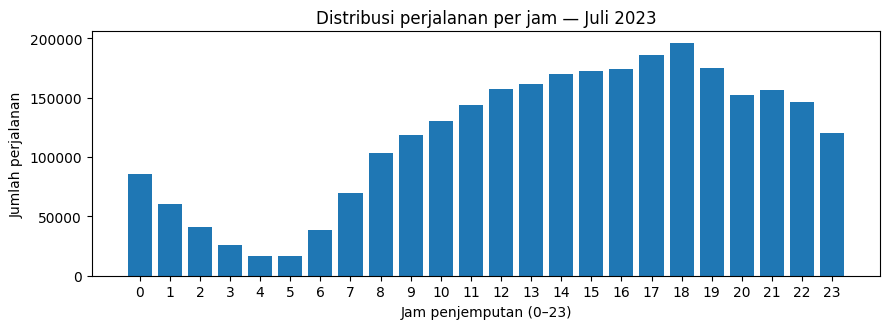

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi_juli["jam"], agregasi_juli["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam — Juli 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam_juli.png", dpi=150)
plt.show()

## Q.2 Perbandingan Dataset Januari dan Juli 2023

Hasil agregasi per jam dari dataset Januari dan Juli 2023 dibandingkan untuk melihat perbedaan pola jumlah perjalanan. Perbandingan disajikan dalam satu tabel dan satu grafik.

In [60]:
perbandingan_bulan = agregasi[["jam", "jumlah_perjalanan"]].merge(
    agregasi_juli[["jam", "jumlah_perjalanan"]],
    on="jam",
    suffixes=("_januari", "_juli")
)

perbandingan_bulan

,jam,jumlah_perjalanan_januari,jumlah_perjalanan_juli
0,0,82289,85987
1,1,57766,59980
2,2,40445,40812
3,3,26146,26000
4,4,16618,16637
5,5,16940,16913
6,6,42300,38422
7,7,84569,69358
8,8,114064,103647
9,9,127988,118788


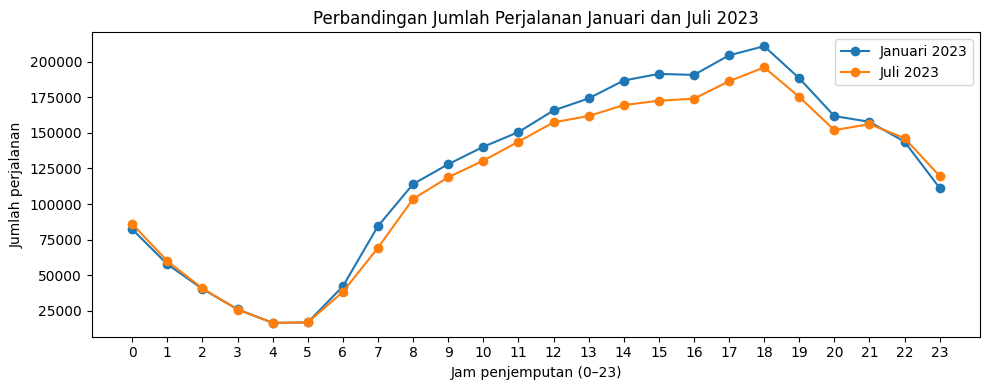

In [61]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(
    perbandingan_bulan["jam"],
    perbandingan_bulan["jumlah_perjalanan_januari"],
    marker="o",
    label="Januari 2023"
)

ax.plot(
    perbandingan_bulan["jam"],
    perbandingan_bulan["jumlah_perjalanan_juli"],
    marker="o",
    label="Juli 2023"
)

ax.set_xlabel("Jam penjemputan (0–23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Perbandingan Jumlah Perjalanan Januari dan Juli 2023")
ax.set_xticks(range(0, 24))
ax.legend()
fig.tight_layout()

fig.savefig(
    f"{DIR_SIMPAN}/perbandingan_januari_juli.png",
    dpi=150
)

plt.show()

bulan mana yang lebih ramai secara keseluruhan dan jam tersibuk masing-masing bulan.

In [62]:
total_januari = agregasi["jumlah_perjalanan"].sum()
total_juli = agregasi_juli["jumlah_perjalanan"].sum()

jam_tertinggi_januari = agregasi.loc[
    agregasi["jumlah_perjalanan"].idxmax()
]
jam_tertinggi_juli = agregasi_juli.loc[
    agregasi_juli["jumlah_perjalanan"].idxmax()
]

print(f"Total perjalanan Januari 2023 : {total_januari:,}")
print(f"Total perjalanan Juli 2023   : {total_juli:,}")

print(
    f"\nJam tersibuk Januari: "
    f"{int(jam_tertinggi_januari['jam']):02d}.00 "
    f"({int(jam_tertinggi_januari['jumlah_perjalanan']):,} perjalanan)"
)

print(
    f"Jam tersibuk Juli: "
    f"{int(jam_tertinggi_juli['jam']):02d}.00 "
    f"({int(jam_tertinggi_juli['jumlah_perjalanan']):,} perjalanan)"
)

Total perjalanan Januari 2023 : 2,986,911
Total perjalanan Juli 2023   : 2,817,657

Jam tersibuk Januari: 18.00 (210,858 perjalanan)
Jam tersibuk Juli: 18.00 (195,988 perjalanan)


## Q.3 Analisis Kinerja

Pengukuran kinerja digunakan untuk membandingkan waktu eksekusi dan perubahan penggunaan memori pada setiap tahap pengolahan data.

In [63]:
pd.DataFrame(catatan)

,langkah,detik,delta_rss_mb
0,unduh dataset,0.39,1.7
1,baca semua kolom,1.37,498.8
2,baca kolom terpilih,0.58,205.0
3,tulis CSV,43.56,5.8
4,agregasi chunking,3.97,11.2
5,spark count,2.80,0.0
6,spark count,0.47,0.0
7,spark agregasi,8.97,0.0
8,unduh dataset Juli,0.30,0.0
9,baca semua kolom Juli,4.07,428.7


In [64]:
kinerja = pd.DataFrame(catatan)

print("Langkah dengan waktu eksekusi paling lama:")
print(kinerja.loc[kinerja["detik"].idxmax()])

print("\nLangkah dengan pertumbuhan RSS terbesar:")
print(kinerja.loc[kinerja["delta_rss_mb"].idxmax()])

Langkah dengan waktu eksekusi paling lama:
langkah         tulis CSV
detik               43.56
delta_rss_mb          5.8
Name: 3, dtype: object

Langkah dengan pertumbuhan RSS terbesar:
langkah         baca semua kolom
detik                       1.37
delta_rss_mb               498.8
Name: 1, dtype: object


Berdasarkan hasil pengukuran kinerja, langkah yang paling mahal dari sisi waktu eksekusi adalah penulisan data ke format CSV. Pada dataset Januari, proses penulisan CSV membutuhkan waktu 43,56 detik, sedangkan pada dataset Juli membutuhkan 40,08 detik. Sementara itu, pembacaan seluruh kolom menjadi proses dengan penggunaan memori terbesar, yaitu 498,8 MB pada Januari dan 428,7 MB pada Juli. Salah satu optimasi yang dapat dilakukan adalah mengurangi penggunaan CSV dan menggunakan format Parquet untuk penyimpanan serta pemrosesan data, karena Parquet memiliki ukuran file yang lebih kecil dan lebih efisien untuk data tabular berukuran besar.

## Q.4 Refleksi Teori

### Refleksi terhadap Dimensi 5V Big Data

Berdasarkan hasil praktikum, data yang digunakan memiliki beberapa karakteristik Big Data, yaitu Volume, Velocity, Variety, Veracity, dan Value.

**Volume.** Dimensi yang paling terlihat adalah Volume. Dataset Januari memiliki sekitar 3 juta baris, sedangkan dataset Juli memiliki sekitar 2,9 juta baris. Pada dataset Juli, pembacaan seluruh 19 kolom membutuhkan memori sekitar 502,5 MB, sedangkan pembacaan hanya 8 kolom yang diperlukan membutuhkan sekitar 177,4 MB. Hal ini menunjukkan bahwa jumlah data yang besar dapat berdampak langsung terhadap penggunaan memori.

**Velocity.** Berdasarkan hasil pengukuran, Velocity belum menjadi karakteristik yang sangat besar pada data ini. Data yang digunakan merupakan data historis dalam bentuk file Parquet, bukan data yang masuk secara real-time. Beberapa proses juga dapat diselesaikan dalam waktu relatif singkat, seperti agregasi Spark pada dataset Juli yang membutuhkan sekitar 1,98 detik. Oleh karena itu, tantangan utama pada praktikum ini lebih banyak berasal dari volume data daripada kecepatan masuknya data.

**Variety.** Dimensi Variety juga tidak terlalu besar karena dataset yang digunakan merupakan data terstruktur dengan format tabular dan memiliki skema kolom yang jelas. Data terutama terdiri dari informasi waktu, jarak perjalanan, tipe pembayaran, tarif, dan beberapa atribut perjalanan lainnya. Dataset Januari dan Juli juga memiliki struktur kolom yang serupa.

**Veracity.** Veracity terlihat dari kebutuhan untuk melakukan pemeriksaan dan pembersihan data. Pada dataset Juli ditemukan data dengan jarak perjalanan kurang dari atau sama dengan 0, durasi tidak valid, durasi lebih dari 180 menit, serta total pembayaran kurang dari atau sama dengan 0. Setelah proses pembersihan, sebanyak 2.817.657 dari 2.907.108 baris dinyatakan layak digunakan.

**Value.** Data dapat memberikan nilai setelah dilakukan pengolahan dan analisis. Agregasi perjalanan berdasarkan jam menunjukkan pola jumlah perjalanan pada waktu tertentu sehingga dapat digunakan untuk memahami periode dengan permintaan tinggi dan rendah. Selain itu, analisis berdasarkan tipe pembayaran dan persentase tip dapat memberikan informasi tambahan mengenai karakteristik perjalanan.

Dari kelima dimensi tersebut, **Volume merupakan dimensi yang paling nyata pada praktikum ini**, sedangkan Velocity dan Variety belum terlalu besar. Hal ini didukung oleh jumlah data yang mencapai jutaan baris dan penggunaan memori hingga sekitar 500 MB ketika seluruh kolom dibaca. Hasil praktikum juga menunjukkan bahwa pemilihan kolom dapat mengurangi penggunaan sumber daya secara signifikan, sehingga strategi pengelolaan data menjadi penting ketika volume data semakin besar.